# Web Server Log Analysis using Apache Spark
## Rajesh Kumar Singh


# Problem Statement
### Overview & background:
#### A U.S.-based firm intends to analyze its web server logs to study application access patterns and determine if changes are needed in its deployment strategy. Two log files in compressed (.gz) format, each corresponding to a different month, have been made available for analysis. These logs follow the Common Log Format (CLF) of Apache and contain valuable information, such as request timestamps, the requesting host, requested resources, response codes, and more. The file names are:
* Access_log_Jul1995.gz
* Access_log_Aug1995.gz

#### Since the logs are large and contain lot of information, they need to be processed and analyzed efficiently using Big Data tools. For this assignment, you will leverage Apache Spark with PySpark and SparkSQL to handle and analyze the logs. You can choose to work with either Google Colab or a local Spark setup for this task.

# Data Wrangling
#### Before performing any analysis, you may perform appropriate data wrangling steps prepare the log data for analysis. These steps may include:

1.Parsing the log files correctly according to the Common Log Format.

2.Handling missing or malformed data.

3.Structuring the data into a format suitable for analysis and presentation.

Document each of the issues encountered during data wrangling and provide a justification for the actions taken to address them.

# Analytics:
Analyze the web server logs to extract the following insights:
#### i.Count of total log records
−Determine the total number of log entries in the dataset.
#### ii.Count of unique hosts:
−Determine the number of unique hosts in the log data.
#### iii.Date wise unique host counts:
−For each date, identify and count the number of unique hosts accessing the web server. List the result in the date order. Print the date in dd-MMM-yyyy format.
#### iv.Average Requests per Host per Day:
−Calculate the average number of requests made per host for each day (day of the month). List the results in the day order.
#### v.Number of 404 Response Codes:
−Identify and count the number of instances where the server returned a 404 (Not Found) response code.
#### vi.Top 15 Endpoints with 404 Responses:
−Identify the endpoints with the most 404 errors and list the top fifteen.
#### vii.Top 15 Hosts with 404 Responses:
−Identify the hosts generating the most 404 errors and list the top fifteen.

# 1. Installing PySpark in Google Colab

In [ ]:
!sudo apt update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://dlcdn.apache.org/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!tar xf spark-3.2.1-bin-hadoop3.2.tgz
!pip install -q findspark
!pip install pyspark
!pip install py4j

import os
import sys
import findspark
import pyspark
findspark.init()
findspark.find()
from pyspark.sql import DataFrame, SparkSession
from typing import List
import pyspark.sql.types as T
import pyspark.sql.functions as F

spark= SparkSession \
       .builder \
       .appName("Web Server Log Analysis using Apache Spark") \
       .getOrCreate()

spark

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [33.6 kB]
Fetched 439 kB in 2s (292 kB/s)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
29 packages can

In [ ]:
#sqlContext

# 1.Load and View the Log Dataset

###  Upload the Server Log files

In [ ]:
from google.colab import files

uploaded = files.upload()  # Opens a file picker to upload files

### View the uploaded Log Files

In [ ]:
import os
import glob

# List all .gz files in /content/
uploaded_files = glob.glob("/content/*.gz")
print("Uploaded files:", uploaded_files)


Uploaded files: ['/content/Aaccess_log_Aug1995-1.gz', '/content/Access_log_Jul1995-1.gz']


In [ ]:
#os.remove("/content/Aaccess_log_Aug1995-1 (1).gz")

In [ ]:
base_df = spark.read.text(uploaded_files)
base_df.printSchema()
type(base_df)
base_df_rdd = base_df.rdd
type(base_df_rdd)
base_df.show(10, truncate=False)

root
 |-- value: string (nullable = true)

+-----------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                  |
+-----------------------------------------------------------------------------------------------------------------------+
|199.72.81.55 - - [01/Jul/1995:00:00:01 -0400] "GET /history/apollo/ HTTP/1.0" 200 6245                                 |
|unicomp6.unicomp.net - - [01/Jul/1995:00:00:06 -0400] "GET /shuttle/countdown/ HTTP/1.0" 200 3985                      |
|199.120.110.21 - - [01/Jul/1995:00:00:09 -0400] "GET /shuttle/missions/sts-73/mission-sts-73.html HTTP/1.0" 200 4085   |
|burger.letters.com - - [01/Jul/1995:00:00:11 -0400] "GET /shuttle/countdown/liftoff.html HTTP/1.0" 304 0               |
|199.120.110.21 - - [01/Jul/1995:00:00:11 -0400] "GET /shuttle/missions/sts-73/sts-73-patch-small.gif H

In [ ]:
base_df_rdd.take(10)

[Row(value='199.72.81.55 - - [01/Jul/1995:00:00:01 -0400] "GET /history/apollo/ HTTP/1.0" 200 6245'),
 Row(value='unicomp6.unicomp.net - - [01/Jul/1995:00:00:06 -0400] "GET /shuttle/countdown/ HTTP/1.0" 200 3985'),
 Row(value='199.120.110.21 - - [01/Jul/1995:00:00:09 -0400] "GET /shuttle/missions/sts-73/mission-sts-73.html HTTP/1.0" 200 4085'),
 Row(value='burger.letters.com - - [01/Jul/1995:00:00:11 -0400] "GET /shuttle/countdown/liftoff.html HTTP/1.0" 304 0'),
 Row(value='199.120.110.21 - - [01/Jul/1995:00:00:11 -0400] "GET /shuttle/missions/sts-73/sts-73-patch-small.gif HTTP/1.0" 200 4179'),
 Row(value='burger.letters.com - - [01/Jul/1995:00:00:12 -0400] "GET /images/NASA-logosmall.gif HTTP/1.0" 304 0'),
 Row(value='burger.letters.com - - [01/Jul/1995:00:00:12 -0400] "GET /shuttle/countdown/video/livevideo.gif HTTP/1.0" 200 0'),
 Row(value='205.212.115.106 - - [01/Jul/1995:00:00:12 -0400] "GET /shuttle/countdown/countdown.html HTTP/1.0" 200 3985'),
 Row(value='d104.aa.net - - [01/Ju

# 2.Data Wrangling

In [ ]:
print(f"\033[1m Dataset Shape -Number of Records, Nos of columns:\033[0m")
print((base_df.count(), len(base_df.columns)))

 Dataset Shape -Number of Records, Nos of columns:
(3461613, 1)


### Working on Sample Message

In [ ]:
sample_logs = [item['value'] for item in base_df.take(5)]
sample_logs

['199.72.81.55 - - [01/Jul/1995:00:00:01 -0400] "GET /history/apollo/ HTTP/1.0" 200 6245',
 'unicomp6.unicomp.net - - [01/Jul/1995:00:00:06 -0400] "GET /shuttle/countdown/ HTTP/1.0" 200 3985',
 '199.120.110.21 - - [01/Jul/1995:00:00:09 -0400] "GET /shuttle/missions/sts-73/mission-sts-73.html HTTP/1.0" 200 4085',
 'burger.letters.com - - [01/Jul/1995:00:00:11 -0400] "GET /shuttle/countdown/liftoff.html HTTP/1.0" 304 0',
 '199.120.110.21 - - [01/Jul/1995:00:00:11 -0400] "GET /shuttle/missions/sts-73/sts-73-patch-small.gif HTTP/1.0" 200 4179']

### Extracting host names from Log

In [ ]:
import re
host_pattern = r'(^\S+\.[\S+\.]+\S+)\s'
hosts = [re.search(host_pattern, item).group(1)
           if re.search(host_pattern, item)
           else 'no match'
           for item in sample_logs]
hosts

['199.72.81.55',
 'unicomp6.unicomp.net',
 '199.120.110.21',
 'burger.letters.com',
 '199.120.110.21']

### Extracting timestamps from Log

In [ ]:
ts_pattern = r'\[(\d{2}/\w{3}/\d{4}:\d{2}:\d{2}:\d{2} -\d{4})]'
timestamps = [re.search(ts_pattern, item).group(1) for item in sample_logs]
timestamps

['01/Jul/1995:00:00:01 -0400',
 '01/Jul/1995:00:00:06 -0400',
 '01/Jul/1995:00:00:09 -0400',
 '01/Jul/1995:00:00:11 -0400',
 '01/Jul/1995:00:00:11 -0400']

### Extracting HTTP Request Method, URIs and Protocol from Log


In [ ]:
method_uri_protocol_pattern = r'\"(\S+)\s(\S+)\s*(\S*)\"'
method_uri_protocol = [re.search(method_uri_protocol_pattern, item).groups()
               if re.search(method_uri_protocol_pattern, item)
               else 'no match'
              for item in sample_logs]
method_uri_protocol

[('GET', '/history/apollo/', 'HTTP/1.0'),
 ('GET', '/shuttle/countdown/', 'HTTP/1.0'),
 ('GET', '/shuttle/missions/sts-73/mission-sts-73.html', 'HTTP/1.0'),
 ('GET', '/shuttle/countdown/liftoff.html', 'HTTP/1.0'),
 ('GET', '/shuttle/missions/sts-73/sts-73-patch-small.gif', 'HTTP/1.0')]

### Extracting HTTP Status Codes from Log

In [ ]:
status_pattern = r'\s(\d{3})\s'
status = [re.search(status_pattern, item).group(1) for item in sample_logs]
print(status)

['200', '200', '200', '304', '200']


### Extracting HTTP Response Content Size from Log

In [ ]:
content_size_pattern = r'\s(\d+)$'
content_size = [re.search(content_size_pattern, item).group(1) for item in sample_logs]
print(content_size)

['6245', '3985', '4085', '0', '4179']


# Build dataframe with all the log attributes neatly extracted in their own separate columns

In [ ]:
from pyspark.sql.functions import regexp_extract

logs_df = base_df.select(regexp_extract('value', host_pattern, 1).alias('host'),
                         regexp_extract('value', ts_pattern, 1).alias('timestamp'),
                         regexp_extract('value', method_uri_protocol_pattern, 1).alias('method'),
                         regexp_extract('value', method_uri_protocol_pattern, 2).alias('endpoint'),
                         regexp_extract('value', method_uri_protocol_pattern, 3).alias('protocol'),
                         regexp_extract('value', status_pattern, 1).cast('integer').alias('status'),
                         regexp_extract('value', content_size_pattern, 1).cast('integer').alias('content_size'))
logs_df.show(5, truncate=False)
print((logs_df.count(), len(logs_df.columns)))

+--------------------+--------------------------+------+-----------------------------------------------+--------+------+------------+
|host                |timestamp                 |method|endpoint                                       |protocol|status|content_size|
+--------------------+--------------------------+------+-----------------------------------------------+--------+------+------------+
|199.72.81.55        |01/Jul/1995:00:00:01 -0400|GET   |/history/apollo/                               |HTTP/1.0|200   |6245        |
|unicomp6.unicomp.net|01/Jul/1995:00:00:06 -0400|GET   |/shuttle/countdown/                            |HTTP/1.0|200   |3985        |
|199.120.110.21      |01/Jul/1995:00:00:09 -0400|GET   |/shuttle/missions/sts-73/mission-sts-73.html   |HTTP/1.0|200   |4085        |
|burger.letters.com  |01/Jul/1995:00:00:11 -0400|GET   |/shuttle/countdown/liftoff.html                |HTTP/1.0|304   |0           |
|199.120.110.21      |01/Jul/1995:00:00:11 -0400|GET   |/shutt

#Finding Missing Values

In [ ]:
print(f"\033[1mFinding Missing Values in log records:\033[0m")
(base_df
    .filter(base_df['value']
                .isNull())
    .count())

Finding Missing Values in log records:


0

# Rows with potential null values

In [ ]:
print(f"\033[1mNumber of rows with potential null values.\033[0m")
bad_rows_df = logs_df.filter(logs_df['host'].isNull()|
                             logs_df['timestamp'].isNull() |
                             logs_df['method'].isNull() |
                             logs_df['endpoint'].isNull() |
                             logs_df['status'].isNull() |
                             logs_df['content_size'].isNull()|
                             logs_df['protocol'].isNull())
bad_rows_df.count()

Number of rows with potential null values.


33905


# Finding Null Counts

In [ ]:
print(f"\033[1mNull Counts for each clumns in log:\033[0m")
from pyspark.sql.functions import col
from pyspark.sql.functions import sum as spark_sum

def count_null(col_name):
    return spark_sum(col(col_name).isNull().cast('integer')).alias(col_name)

# Build up a list of column expressions, one per column.
exprs = [count_null(col_name) for col_name in logs_df.columns]

# Run the aggregation. The *exprs converts the list of expressions into
# variable function arguments.
logs_df.agg(*exprs).show()

Null Counts for each clumns in log:
+----+---------+------+--------+--------+------+------------+
|host|timestamp|method|endpoint|protocol|status|content_size|
+----+---------+------+--------+--------+------+------------+
|   0|        0|     0|       0|       0|     1|       33905|
+----+---------+------+--------+--------+------+------------+



# Handling nulls in HTTP status

In [ ]:
from pyspark.sql.functions import col
from pyspark.sql.functions import sum as spark_sum

def count_null(col_name):
    return spark_sum(col(col_name).isNull().cast('integer')).alias(col_name)

# Build up a list of column expressions, one per column.
exprs = [count_null(col_name) for col_name in logs_df.columns]

# Run the aggregation. The *exprs converts the list of expressions into
# variable function arguments.
logs_df.agg(*exprs).show()

+----+---------+------+--------+--------+------+------------+
|host|timestamp|method|endpoint|protocol|status|content_size|
+----+---------+------+--------+--------+------+------------+
|   0|        0|     0|       0|       0|     1|       33905|
+----+---------+------+--------+--------+------+------------+



In [ ]:
null_status_df = base_df.filter(~base_df['value'].rlike(r'\s(\d{3})\s'))
null_status_df.count()
bad_status_df = null_status_df.select(regexp_extract('value', host_pattern, 1).alias('host'),
                                      regexp_extract('value', ts_pattern, 1).alias('timestamp'),
                                      regexp_extract('value', method_uri_protocol_pattern, 1).alias('method'),
                                      regexp_extract('value', method_uri_protocol_pattern, 2).alias('endpoint'),
                                      regexp_extract('value', method_uri_protocol_pattern, 3).alias('protocol'),
                                      regexp_extract('value', status_pattern, 1).cast('integer').alias('status'),
                                      regexp_extract('value', content_size_pattern, 1).cast('integer').alias('content_size'))
bad_status_df.show(truncate=False)

+----+---------+------+--------+--------+------+------------+
|host|timestamp|method|endpoint|protocol|status|content_size|
+----+---------+------+--------+--------+------+------------+
|    |         |      |        |        |NULL  |NULL        |
+----+---------+------+--------+--------+------+------------+



### -This record is incomplete and lacks useful information. The best approach is to remove it using the following method.

In [ ]:
logs_df = logs_df[logs_df['status'].isNotNull()]
exprs = [count_null(col_name) for col_name in logs_df.columns]
logs_df.agg(*exprs).show()

+----+---------+------+--------+--------+------+------------+
|host|timestamp|method|endpoint|protocol|status|content_size|
+----+---------+------+--------+--------+------+------------+
|   0|        0|     0|       0|       0|     0|       33904|
+----+---------+------+--------+--------+------+------------+



# Handling nulls in HTTP content size

In [ ]:
null_content_size_df = base_df.filter(~base_df['value'].rlike(r'\s\d+$'))
null_content_size_df.count()

33905

In [ ]:
null_content_size_df.take(10)

[Row(value='dd15-062.compuserve.com - - [01/Jul/1995:00:01:12 -0400] "GET /news/sci.space.shuttle/archive/sci-space-shuttle-22-apr-1995-40.txt HTTP/1.0" 404 -'),
 Row(value='dynip42.efn.org - - [01/Jul/1995:00:02:14 -0400] "GET /software HTTP/1.0" 302 -'),
 Row(value='ix-or10-06.ix.netcom.com - - [01/Jul/1995:00:02:40 -0400] "GET /software/winvn HTTP/1.0" 302 -'),
 Row(value='ix-or10-06.ix.netcom.com - - [01/Jul/1995:00:03:24 -0400] "GET /software HTTP/1.0" 302 -'),
 Row(value='link097.txdirect.net - - [01/Jul/1995:00:05:06 -0400] "GET /shuttle HTTP/1.0" 302 -'),
 Row(value='ix-war-mi1-20.ix.netcom.com - - [01/Jul/1995:00:05:13 -0400] "GET /shuttle/missions/sts-78/news HTTP/1.0" 302 -'),
 Row(value='ix-war-mi1-20.ix.netcom.com - - [01/Jul/1995:00:05:58 -0400] "GET /shuttle/missions/sts-72/news HTTP/1.0" 302 -'),
 Row(value='netport-27.iu.net - - [01/Jul/1995:00:10:19 -0400] "GET /pub/winvn/readme.txt HTTP/1.0" 404 -'),
 Row(value='netport-27.iu.net - - [01/Jul/1995:00:10:28 -0400] "GET

It is clear that the bad raw data records correspond to error responses, where no content was returned, and the server indicated this with a "-" in the content_size field.

Rather than discarding these rows from our analysis, we will impute them by filling the missing values with 0.

# Fix the rows with null content size

In [ ]:
logs_df = logs_df.na.fill({'content_size': 0})
exprs = [count_null(col_name) for col_name in logs_df.columns]
logs_df.agg(*exprs).show()

+----+---------+------+--------+--------+------+------------+
|host|timestamp|method|endpoint|protocol|status|content_size|
+----+---------+------+--------+--------+------+------------+
|   0|        0|     0|       0|       0|     0|           0|
+----+---------+------+--------+--------+------+------------+



# Handling Temporal Fields (Timestamp)

#### With our DataFrame now clean and well-structured, the next step is to convert the timestamp field into a proper datetime format. Since the Common Log Format uses a non-standard timestamp, the most efficient approach for parsing it is through a User-Defined Function (UDF).

In [ ]:
from pyspark.sql.functions import udf

month_map = {
  'Jan': 1, 'Feb': 2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6, 'Jul':7,
  'Aug':8,  'Sep': 9, 'Oct':10, 'Nov': 11, 'Dec': 12
}

def parse_clf_time(text):
    # NOTE: We're ignoring the time zone.
    return "{0:04d}-{1:02d}-{2:02d} {3:02d}:{4:02d}:{5:02d}".format(
      int(text[7:11]),
      month_map[text[3:6]],
      int(text[0:2]),
      int(text[12:14]),
      int(text[15:17]),
      int(text[18:20])
    )

In [ ]:
udf_parse_time = udf(parse_clf_time)

logs_df = (logs_df.select('*', udf_parse_time(logs_df['timestamp'])
                                  .cast('timestamp')
                                  .alias('time'))
                  .drop('timestamp'))
logs_df.show(10, truncate=True)

+--------------------+------+--------------------+--------+------+------------+-------------------+
|                host|method|            endpoint|protocol|status|content_size|               time|
+--------------------+------+--------------------+--------+------+------------+-------------------+
|        199.72.81.55|   GET|    /history/apollo/|HTTP/1.0|   200|        6245|1995-07-01 00:00:01|
|unicomp6.unicomp.net|   GET| /shuttle/countdown/|HTTP/1.0|   200|        3985|1995-07-01 00:00:06|
|      199.120.110.21|   GET|/shuttle/missions...|HTTP/1.0|   200|        4085|1995-07-01 00:00:09|
|  burger.letters.com|   GET|/shuttle/countdow...|HTTP/1.0|   304|           0|1995-07-01 00:00:11|
|      199.120.110.21|   GET|/shuttle/missions...|HTTP/1.0|   200|        4179|1995-07-01 00:00:11|
|  burger.letters.com|   GET|/images/NASA-logo...|HTTP/1.0|   304|           0|1995-07-01 00:00:12|
|  burger.letters.com|   GET|/shuttle/countdow...|HTTP/1.0|   200|           0|1995-07-01 00:00:12|


### Everything appears to be in order.Check schema of Log DataFram

In [ ]:
print(f"\033[1mPrint Schemma for Log DataFrame:\033[0m")
logs_df.printSchema()

Print Schemma for Log DataFrame:
root
 |-- host: string (nullable = true)
 |-- method: string (nullable = true)
 |-- endpoint: string (nullable = true)
 |-- protocol: string (nullable = true)
 |-- status: integer (nullable = true)
 |-- content_size: integer (nullable = false)
 |-- time: timestamp (nullable = true)



In [ ]:
print(f"\033[1mCache the DataFrame:\033[0m")
logs_df.cache()     # stores the DataFrame in memory for faster access.
#logs_df.unpersist() # Removes the cached data from memory to free up space.


Cache the DataFrame:


DataFrame[host: string, method: string, endpoint: string, protocol: string, status: int, content_size: int, time: timestamp]

# 3.Data Analysis on our Web Logs using Pyspark and SparkSQL

In [ ]:
# Register Temp View
logs_df.createOrReplaceTempView("logs")

Note : Temporary SQL view named "logs" created, allow to run SQL queries directly on the logs_df DataFrame using Spark SQL

# 1.Count of total log records
- Total number of log entries in the dataset.

In [ ]:
# 1. Total Log Records
result_1_df = spark.sql("SELECT COUNT(*) AS Total_logs FROM logs")

print(f"\033[1mTotal number of log records.\033[0m")
result_1_df.show()
print(f"\033[1mNote: One records has null status so not included in Count. Total Records:-3461613\033[0m")

Total number of log records.
+----------+
|Total_logs|
+----------+
|   3461612|
+----------+

Note: One records has null status so not included in Count. Total Records:-3461613


# 2.Count of unique hosts:
Number of unique hosts in the log data.

In [ ]:
# 2. Count of Unique Hosts
result_2_df =  spark.sql("SELECT COUNT(DISTINCT host) AS Unique_hosts FROM logs")

print(f"\033[1m Count of unique Hosts.\033[0m")
result_2_df.show()

 Count of unique Hosts.
+------------+
|Unique_hosts|
+------------+
|      137933|
+------------+



# 3. Date wise unique host counts:
−
For each date, identify and count the number of unique hosts accessing the web server. List the result in the date order. Print the date in dd-MMM-yyyy format.

In [ ]:
# 3. Date-wise Unique Host Counts
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")

result_3_df =  spark.sql("""WITH formatted_logs AS (
    SELECT
        TO_DATE(TO_TIMESTAMP(time, 'dd/MMM/yyyy:HH:mm:ss')) AS date,
        host
    FROM logs
),
unique_hosts_per_date AS (
    SELECT
        date,
        COUNT(DISTINCT host) AS unique_hosts
    FROM formatted_logs
    GROUP BY date
)
SELECT
    DATE_FORMAT(date, 'dd-MMM-yyyy') AS Dates,
    Unique_Hosts
FROM unique_hosts_per_date
ORDER BY date ASC;  -- Ensure sorting happens before formatting
 """)
print(f"\033[1mDate-wise Unique Host Counts:\033[0m")

result_3_df.show(62, truncate=False)

Date-wise Unique Host Counts:
+-----------+------------+
|Dates      |Unique_Hosts|
+-----------+------------+
|01-Jul-1995|5191        |
|02-Jul-1995|4858        |
|03-Jul-1995|7332        |
|04-Jul-1995|5523        |
|05-Jul-1995|7379        |
|06-Jul-1995|7815        |
|07-Jul-1995|6471        |
|08-Jul-1995|2898        |
|09-Jul-1995|2554        |
|10-Jul-1995|4460        |
|11-Jul-1995|4923        |
|12-Jul-1995|5339        |
|13-Jul-1995|6946        |
|14-Jul-1995|5292        |
|15-Jul-1995|3115        |
|16-Jul-1995|3013        |
|17-Jul-1995|4941        |
|18-Jul-1995|4518        |
|19-Jul-1995|4913        |
|20-Jul-1995|4725        |
|21-Jul-1995|4337        |
|22-Jul-1995|2575        |
|23-Jul-1995|2634        |
|24-Jul-1995|4294        |
|25-Jul-1995|4373        |
|26-Jul-1995|4295        |
|27-Jul-1995|4367        |
|28-Jul-1995|2173        |
|01-Aug-1995|2578        |
|03-Aug-1995|3220        |
|04-Aug-1995|4189        |
|05-Aug-1995|2502        |
|06-Aug-1995|2537        

# 4.Average Requests per Host per Day:
−
Calculate the average number of requests made per host for each day (day of the month). List the results in the day order.


In [ ]:
# Average Requests Per Host Per Day

result_4_df = spark.sql("""
    SELECT
        d.day,
        d.total_hosts,
        r.total_reqs,
        ROUND(r.total_reqs / d.total_hosts,2) AS avg_reqs
    FROM
        (SELECT dayofmonth(time) AS day, COUNT(DISTINCT host) AS total_hosts
         FROM logs
         GROUP BY day) d
    JOIN
        (SELECT dayofmonth(time) AS day, COUNT(*) AS total_reqs
         FROM logs
         GROUP BY day) r
    ON d.day = r.day
    ORDER BY d.day
""")
print(f"\033[1mAverage Requests per Host per Day:\033[0m")
result_4_df.show(62, truncate=False)

Average Requests per Host per Day:
+---+-----------+----------+--------+
|day|total_hosts|total_reqs|avg_reqs|
+---+-----------+----------+--------+
|1  |7609       |98710     |12.97   |
|2  |4858       |60265     |12.41   |
|3  |10238      |130972    |12.79   |
|4  |9411       |130009    |13.81   |
|5  |9640       |126468    |13.12   |
|6  |10133      |133380    |13.16   |
|7  |10048      |144595    |14.39   |
|8  |7112       |99024     |13.92   |
|9  |6699       |95730     |14.29   |
|10 |8532       |134108    |15.72   |
|11 |8786       |141653    |16.12   |
|12 |8135       |130607    |16.05   |
|13 |9567       |170683    |17.84   |
|14 |9302       |143981    |15.48   |
|15 |7126       |104379    |14.65   |
|16 |7143       |104507    |14.63   |
|17 |8840       |133969    |15.15   |
|18 |8262       |120528    |14.59   |
|19 |7237       |104832    |14.49   |
|20 |7072       |99556     |14.08   |
|21 |8036       |120169    |14.95   |
|22 |6828       |93029     |13.62   |
|23 |6797      

# Visualization: Average Requests per Host per Day

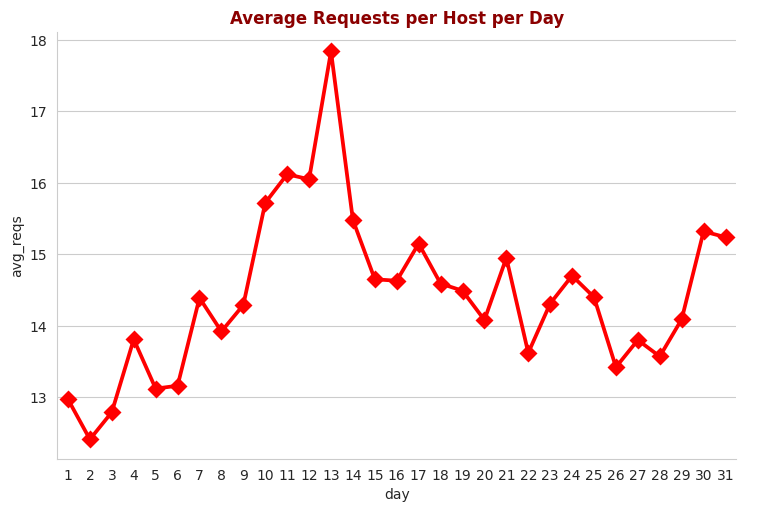

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark DataFrame to Pandas
result_4_pd = result_4_df.toPandas()

# Set style
sns.set_style("whitegrid")

# Create the plot
sns.catplot(x='day', y='avg_reqs',
            data=result_4_pd,
            kind='point', height=5, aspect=1.5,
            markers="D", color="Red")

# Add title
plt.title("Average Requests per Host per Day", fontsize=12, fontweight='bold', color='darkred')

# Show plot
plt.show()


### Observation
The graph shows a rising trend in average requests per host, peaking sharply on day 13 before fluctuating. Most values range between 13 requests, with another increase around days 30 and 31. The red diamond markers effectively highlight variations in daily request patterns

# 5.Number of 404 Response Codes:
−
Identify and count the number of instances where the server returned a 404 (Not Found) response code.

In [ ]:
# 5. Count of 404 Responses
result_5_df = spark.sql("SELECT COUNT(*) AS Total_404_errors FROM logs WHERE status = 404")

print(f"\033[1mNumber of 404 response codes:\033[0m")
result_5_df.show()

Number of 404 response codes:
+----------------+
|Total_404_errors|
+----------------+
|           20899|
+----------------+



# 6.Top 15 Endpoints with 404 Responses:
− Identify the endpoints with the most 404 errors and list the top fifteen.

In [ ]:
# 6. Top 15 Endpoints with 404 Responses
result_6_df = spark.sql("SELECT Endpoint, COUNT(*) AS Count FROM logs WHERE status = 404 GROUP BY endpoint ORDER BY count DESC LIMIT 15")
print(f"\033[1mTop 15 Endpoints with 404 Responses:\033[0m")
result_6_df.show(truncate=False)

Top 15 Endpoints with 404 Responses:
+-----------------------------------------------------------------+-----+
|Endpoint                                                         |Count|
+-----------------------------------------------------------------+-----+
|/pub/winvn/readme.txt                                            |2004 |
|/pub/winvn/release.txt                                           |1732 |
|/shuttle/missions/STS-69/mission-STS-69.html                     |683  |
|/shuttle/missions/sts-68/ksc-upclose.gif                         |428  |
|/history/apollo/a-001/a-001-patch-small.gif                      |384  |
|/history/apollo/sa-1/sa-1-patch-small.gif                        |383  |
|/://spacelink.msfc.nasa.gov                                      |381  |
|/images/crawlerway-logo.gif                                      |374  |
|/elv/DELTA/uncons.htm                                            |372  |
|/history/apollo/pad-abort-test-1/pad-abort-test-1-patch-small.gif|359  |
|

# Visualization: Top 15 Endpoints with 404 Responses

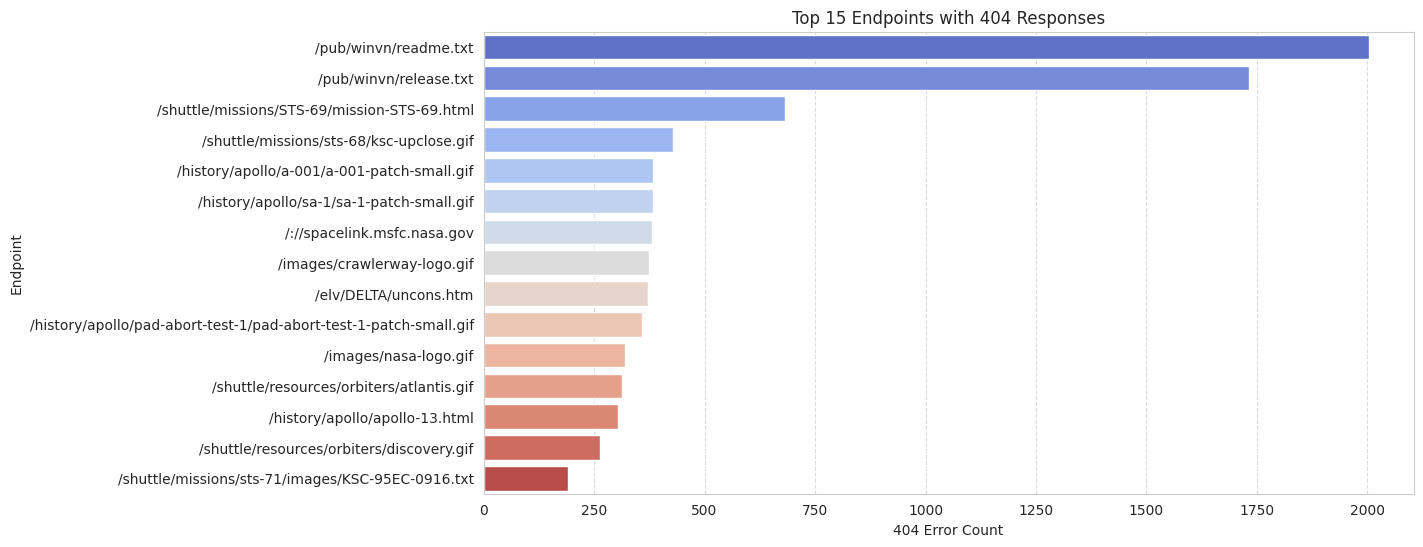

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark DataFrame to Pandas
result_6_pd = result_6_df.toPandas()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(y=result_6_pd["Endpoint"],hue=result_6_pd["Endpoint"],x=result_6_pd["Count"], palette="coolwarm",legend=False)

# Labels and title
plt.xlabel("404 Error Count")
plt.ylabel("Endpoint")
plt.title("Top 15 Endpoints with 404 Responses")
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show plot
plt.show()

### Observation
The top two endpoints (/pub/winwn/readme.txt and /pub/winwn/release.txt) have the highest 404 errors, significantly more than others. Many missing files relate to historical missions, including images and HTML pages. The errors likely stem from outdated links, missing resources, or incorrect URL references, requiring fixes, redirects, or content restoration.

# 7.Top 15 Hosts with 404 Responses:
−
Identify the hosts generating the most 404 errors and list the top fifteen.

In [ ]:
# 7. Top 15 Hosts with 404 Responses
result_7_df = spark.sql("""SELECT host, COUNT(*) AS count
FROM logs
WHERE status = 404 AND host IS NOT NULL AND TRIM(host) != ''
GROUP BY host
ORDER BY count DESC
LIMIT 15""")
print(f"\033[1mTop 15 Hosts with 404 Responses:\033[0m")
result_7_df.show(truncate=False)


print(f"\033[1m Note:Only non-empty hostnames are included in the result.\033[0m")


Top 15 Hosts with 404 Responses:
+---------------------------+-----+
|host                       |count|
+---------------------------+-----+
|hoohoo.ncsa.uiuc.edu       |251  |
|piweba3y.prodigy.com       |157  |
|jbiagioni.npt.nuwc.navy.mil|132  |
|piweba1y.prodigy.com       |114  |
|www-d4.proxy.aol.com       |91   |
|piweba4y.prodigy.com       |86   |
|scooter.pa-x.dec.com       |69   |
|www-d1.proxy.aol.com       |64   |
|phaelon.ksc.nasa.gov       |64   |
|www-b4.proxy.aol.com       |62   |
|dialip-217.den.mmc.com     |62   |
|www-b3.proxy.aol.com       |61   |
|www-a2.proxy.aol.com       |60   |
|piweba2y.prodigy.com       |59   |
|www-d2.proxy.aol.com       |59   |
+---------------------------+-----+

 Note:Only non-empty hostnames are included in the result.


# Visualization: Top 15 Hosts with 404 Responses

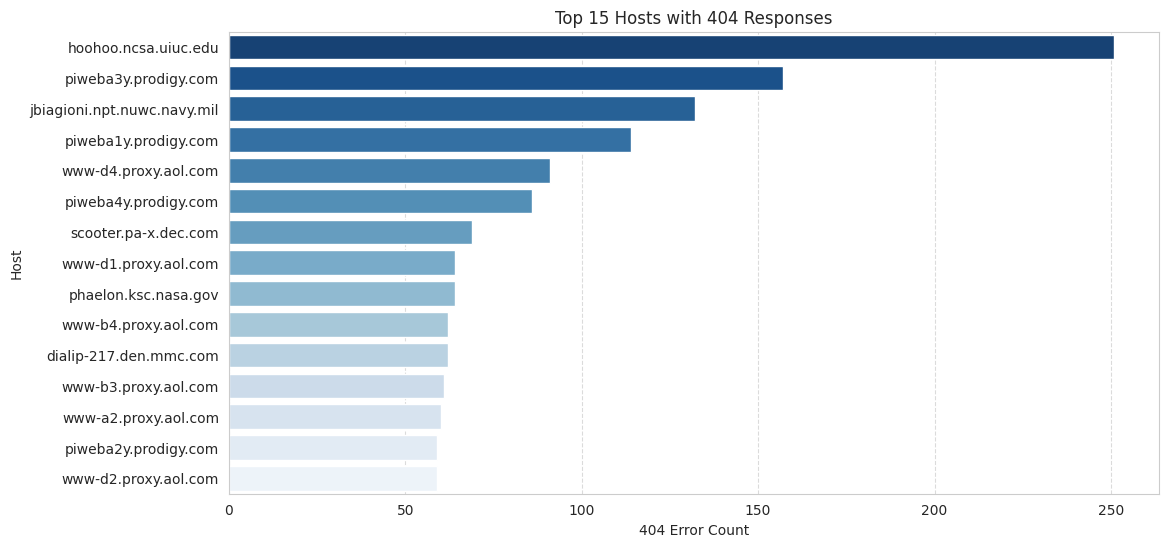

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark DataFrame to Pandas
result_7_pd = result_7_df.toPandas()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(y=result_7_pd["host"],hue=result_7_pd["host"],x=result_7_pd["count"], palette="Blues_r",legend=False)

# Labels and title
plt.xlabel("404 Error Count")
plt.ylabel("Host")
plt.title("Top 15 Hosts with 404 Responses")
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show plot
plt.show()


### Observation
The host hoohoo.ncsa.uiuc.edu has the highest 404 errors, followed by piweba3y.prodigy.com and jbiagioni.npt.nuwc.navy.mil. Many errors come from Prodigy and AOL proxy servers, along with some NASA and military domains. These errors may be due to outdated links, proxy misconfigurations, or attempts to access removed content.

## Conclusion

The use of Apache Spark for log analytics enabled efficient processing of large-scale data, allowing for in-depth analysis and insights. The structured approach ensured data quality and meaningful results, providing actionable intelligence for system monitoring and optimization.

<<<<<<<<<<<<<<<<<<<<<<**Thanks**>>>>>>>>>>>>>>>>>>>>>